# Stage 3 — Compare against Noam's cycle-detection method

Two independent approaches to the same problem (find movement cycles in a
hand-relative-to-root signal, then describe each cycle):

- **Ours**: Hilbert phase on hand-Y-relative-to-root → cycle boundaries at
  phase = k·2π → local 3-D PCA plane per cycle (`fit_pca_phase_coordinates`,
  already run for all 58 runs x 2 hands in Stage 2, cached).
- **Noam's**: Savitzky-Golay smoothing → peak/trough detection (skill- and
  hand-specific thresholds) on the same signal → cycles between consecutive
  events (`extract_cycles_from_signal`, from `Labeled_data_analyses.ipynb`
  Section 5, reused verbatim below).

**3.1** checks whether the two methods agree on *where* cycles are and
whether our phase estimate itself behaved well. **3.2** compares cycle-level
statistics and mean-cycle shape for the 6 primary (longest-per-condition)
blocks. Nothing is refit — this notebook only reads Stage 2's cache.

In [1]:
import sys, pickle
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, find_peaks

sys.path.insert(0, str(Path.cwd()))
import _loading as L
import _plotting as P
from phase_coordinates import reconstruct_phase_coordinates

with open("cache/pca_results.pkl", "rb") as f:
    PCA_CACHE = pickle.load(f)

RUNS_DF = L.list_available_blocks(subject="002")
print("cached fits:", len(PCA_CACHE), " | runs table rows:", len(RUNS_DF))


Detected hostname: fedora-donchin-office
Using root directory: /home/opher/Repositories/phase-coordinates/test_data
Detected hostname: fedora-donchin-office
Using root directory: /home/opher/Repositories/phase-coordinates/test_data


cached fits: 116  | runs table rows: 58


## Noam's cycle-detection method (reused verbatim, concrete params filled in)

In [2]:
FS_HZ = 60.0

CYCLE_PARAMS = {
    "sampling_frequency_hz": FS_HZ, "max_gap_to_bridge_frames": 15, "min_run_duration_sec": 3.0,
    "normalized_cycle_points": 100, "min_cycles_per_subject_hand": 3, "candidate_diagnostics_version": 1,
    "subjects": ("002",), "skills": ("walk", "jump", "climb"), "hands": ("r_hand", "l_hand"),
    "day_part_map": {1: "s", 3: "e"},
    "detection": {
        "walk": {"event_type_by_hand": {"r_hand": "peaks", "l_hand": "troughs"}, "smooth_window": 9, "smooth_polyorder": 3,
                 "prominence_sd_factor": 0.10, "min_event_distance_sec": 0.20, "min_cycle_duration_sec": 0.50,
                 "max_cycle_duration_sec": 3.10, "min_cycle_amplitude": 10},
        "jump": {"event_type_by_hand": {"r_hand": "peaks", "l_hand": "peaks"}, "smooth_window": 9, "smooth_polyorder": 3,
                 "prominence_sd_factor": 0.10, "min_event_distance_sec": 0.20, "min_cycle_duration_sec": 0.40,
                 "max_cycle_duration_sec": 1.50, "min_cycle_amplitude": None},
        "climb": {"event_type_by_hand": {"r_hand": "peaks", "l_hand": "peaks"}, "smooth_window": 9, "smooth_polyorder": 3,
                  "prominence_sd_factor": 0.10, "min_event_distance_sec": 0.20, "min_cycle_duration_sec": 0.40,
                  "max_cycle_duration_sec": 1.70, "min_cycle_amplitude": None},
    },
}


def smooth_signal(values, window_length, polyorder):
    values = np.asarray(values, dtype=float)
    if len(values) < 5: return values.copy()
    window_length = int(window_length) + (int(window_length) % 2 == 0)
    maximum = len(values) if len(values) % 2 else len(values) - 1
    window_length = min(window_length, maximum)
    if window_length <= polyorder or window_length < 5: return values.copy()
    return savgol_filter(values, window_length, polyorder)


def extract_cycles_from_signal(raw, skill, hand, parameters):
    """Verbatim from Noam's Labeled_data_analyses.ipynb Section 5."""
    config = parameters["detection"][skill]; fps = parameters["sampling_frequency_hz"]
    smooth = smooth_signal(raw, config["smooth_window"], config["smooth_polyorder"])
    event_type = config["event_type_by_hand"][hand]
    prominence = config["prominence_sd_factor"] * np.nanstd(smooth)
    distance = max(1, round(config["min_event_distance_sec"] * fps))
    events, _ = find_peaks(smooth if event_type == "peaks" else -smooth, distance=distance, prominence=prominence)
    rejected = {"too_short": 0, "too_long": 0, "nan": 0, "low_amplitude": 0, "resample_failed": 0}
    cycles, candidates = [], []
    for cycle_id, (start, end) in enumerate(zip(events[:-1], events[1:]), 1):
        frames = int(end - start); duration = frames / fps
        candidate = {"cycle_id_in_run": cycle_id, "start_idx_in_run": int(start), "end_idx_in_run": int(end),
                     "duration_frames": frames, "duration_sec": duration, "rejection_reason": "accepted"}
        if duration < config["min_cycle_duration_sec"]:
            rejected["too_short"] += 1; candidate["rejection_reason"] = "too_short"; candidates.append(candidate); continue
        if duration > config["max_cycle_duration_sec"]:
            rejected["too_long"] += 1; candidate["rejection_reason"] = "too_long"; candidates.append(candidate); continue
        raw_cycle, smooth_cycle = raw[start:end + 1], smooth[start:end + 1]
        if not np.isfinite(smooth_cycle).all():
            rejected["nan"] += 1; candidate["rejection_reason"] = "nan"; candidates.append(candidate); continue
        amplitude = float(np.ptp(smooth_cycle))
        candidate["amplitude"] = amplitude
        if config["min_cycle_amplitude"] is not None and amplitude < config["min_cycle_amplitude"]:
            rejected["low_amplitude"] += 1; candidate["rejection_reason"] = "low_amplitude"; candidates.append(candidate); continue
        normalized = np.interp(np.linspace(0, 1, parameters["normalized_cycle_points"]), np.linspace(0, 1, len(smooth_cycle)), smooth_cycle)
        if not np.isfinite(normalized).all():
            rejected["resample_failed"] += 1; candidate["rejection_reason"] = "resample_failed"; candidates.append(candidate); continue
        candidates.append(candidate)
        cycles.append({"cycle_id_in_run": cycle_id, "start_idx_in_run": int(start), "end_idx_in_run": int(end),
                       "duration_frames": frames, "duration_sec": duration, "amplitude": amplitude,
                       "event_type": event_type, "y_cycle_raw": raw_cycle, "y_cycle_smooth": smooth_cycle, "y_cycle_norm": normalized})
    return cycles, candidates, smooth, events, prominence, rejected


def raw_signal_for_run(subject, day, part, skill, run_id, hand):
    """Load the exact raw hand-Y-relative-to-root signal for one cached run,
    keyed by movement_run_id (not positional run_index)."""
    match = RUNS_DF[(RUNS_DF.subject == subject) & (RUNS_DF.day == day) & (RUNS_DF.part == part)
                     & (RUNS_DF.skill == skill) & (RUNS_DF.movement_run_id == run_id)]
    row = match.iloc[0]
    frame = L.load_position_file(row["path"]).iloc[int(row["run_start"]):int(row["run_end"])]
    return (pd.to_numeric(frame[f"{hand}.y"]) - pd.to_numeric(frame["root.y"])).to_numpy(dtype=float)


## 3.1 — Hilbert-consistency check

(a) Boundary-time agreement: for every cached run x hand, compare our
Hilbert-phase cycle-boundary times (start/stop of each fitted cycle) to
Noam's peak/trough event times on the *identical* raw signal, via
nearest-neighbor matching. (b) Phase-quality: whether `hilbert_phase` (run
during Stage 2) flagged non-monotonic phase for that run.

In [3]:
boundary_offset_rows = []
phase_warning_rows = []
skipped_31 = []

for key, entry in PCA_CACHE.items():
    subject, day, part, skill, source_file, run_id, hand = key
    cycles, meta = entry["cycles"], entry["meta"]
    phase_warning_rows.append({"skill": skill, "has_phase_warning": bool(meta.get("warnings"))})

    if cycles.empty:
        skipped_31.append({"subject": subject, "day": day, "part": part, "skill": skill,
                            "run_id": run_id, "hand": hand, "reason": "no_cycles"})
        continue

    hilbert_boundaries = np.array(sorted(cycles["time_start"].tolist() + [cycles["time_stop"].iloc[-1]]))

    try:
        raw = raw_signal_for_run(subject, day, part, skill, run_id, hand)
    except Exception as exc:
        skipped_31.append({"subject": subject, "day": day, "part": part, "skill": skill,
                            "run_id": run_id, "hand": hand, "reason": f"raw_signal_error: {exc}"})
        continue

    _, _, _, noam_events_frames, _, _ = extract_cycles_from_signal(raw, skill, hand, CYCLE_PARAMS)
    if len(noam_events_frames) < 2:
        skipped_31.append({"subject": subject, "day": day, "part": part, "skill": skill,
                            "run_id": run_id, "hand": hand, "reason": "noam_too_few_events"})
        continue
    noam_event_times = noam_events_frames / FS_HZ

    # Nearest-neighbor offset for each Hilbert boundary -> nearest Noam event.
    offsets = np.min(np.abs(hilbert_boundaries[:, None] - noam_event_times[None, :]), axis=1)
    for off in offsets:
        boundary_offset_rows.append({"skill": skill, "hand": hand, "offset_sec": float(off)})

offsets_df = pd.DataFrame(boundary_offset_rows)
warn_df = pd.DataFrame(phase_warning_rows)

print(f"Runs skipped in 3.1: {len(skipped_31)} / {len(PCA_CACHE)}")
if skipped_31:
    print(pd.DataFrame(skipped_31)["reason"].value_counts())

print("\nBoundary-time offset (sec) -- Hilbert cycle boundary vs. nearest Noam event, by skill:")
print(offsets_df.groupby("skill")["offset_sec"].agg(["median", lambda s: s.quantile(0.25),
                                                       lambda s: s.quantile(0.75), "count"])
      .rename(columns={"<lambda_0>": "q25", "<lambda_1>": "q75"}))

print("\nHilbert phase-monotonicity warnings, by skill (True = phase_coordinates flagged this run):")
print(warn_df.groupby("skill")["has_phase_warning"].agg(["sum", "count"]))


Runs skipped in 3.1: 0 / 116

Boundary-time offset (sec) -- Hilbert cycle boundary vs. nearest Noam event, by skill:
         median       q25       q75  count
skill                                     
climb  0.183333  0.150000  0.266667    672
jump   0.200000  0.183333  0.233333    651
walk   0.166667  0.133333  0.250000    670

Hilbert phase-monotonicity warnings, by skill (True = phase_coordinates flagged this run):
       sum  count
skill            
climb    0     34
jump     1     40
walk     0     42


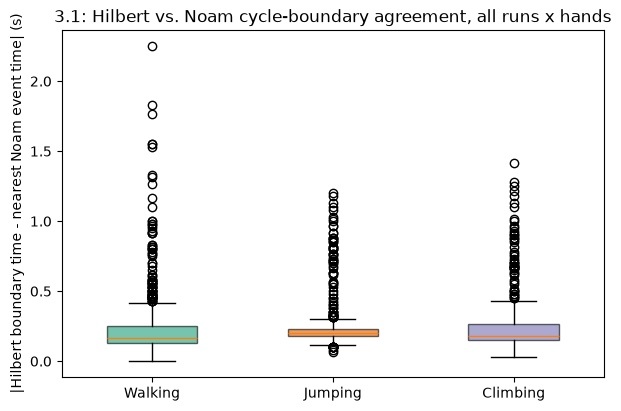

In [4]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for skill in ["walk", "jump", "climb"]:
    vals = offsets_df.loc[offsets_df.skill == skill, "offset_sec"]
    ax.boxplot(vals, positions=[["walk", "jump", "climb"].index(skill)], widths=0.5,
               patch_artist=True, boxprops=dict(facecolor=P.SKILL_COLORS[skill], alpha=0.6))
ax.set_xticks(range(3), [P.SKILL_LABELS[s] for s in ["walk", "jump", "climb"]])
ax.set_ylabel("|Hilbert boundary time - nearest Noam event time| (s)")
ax.set_title("3.1: Hilbert vs. Noam cycle-boundary agreement, all runs x hands")
P.save_figure(fig, "stage3_hilbert_vs_noam_boundary_offset")
plt.show()


## 3.2 — Side-by-side: cycle count, duration, and mean-cycle shape

For each of the 6 primary (longest-per-condition) blocks: run Noam's
extraction on the raw signal, and compare to our cached PCA cycles. For a
shared basis for the mean-cycle-shape overlay, we reconstruct our fitted
3-D trajectory (`reconstruct_phase_coordinates`) and take the hand-Y-
relative-to-root component (column index 1 of the reconstructed X) — this
is exactly the same physical quantity as Noam's `y_cycle_norm`, just derived
from our fitted model instead of the raw signal, so the two mean curves are
directly comparable.

In [5]:
primary_rows = (RUNS_DF.sort_values("run_duration_sec", ascending=False)
                .groupby(["day", "part", "skill"], as_index=False).first())

comparison_rows = []
mean_shapes = {}  # (day, part, skill, hand) -> {"noam": arr, "ours": arr}

for _, prow in primary_rows.iterrows():
    day, part, skill, run_id, source_file = prow.day, prow.part, prow.skill, prow.movement_run_id, prow.source_file
    for hand in ["r_hand", "l_hand"]:
        key = ("002", day, part, skill, source_file, run_id, hand)
        if key not in PCA_CACHE:
            continue
        entry = PCA_CACHE[key]
        our_cycles = entry["cycles"]
        if our_cycles.empty:
            continue

        raw = raw_signal_for_run("002", day, part, skill, run_id, hand)
        noam_cycles, _, _, _, _, _ = extract_cycles_from_signal(raw, skill, hand, CYCLE_PARAMS)

        comparison_rows.append({
            "day": day, "part": part, "skill": skill, "hand": hand,
            "n_cycles_ours": len(our_cycles), "n_cycles_noam": len(noam_cycles),
            "median_duration_ours": our_cycles["duration"].median(),
            "median_duration_noam": (np.median([c["duration_sec"] for c in noam_cycles])
                                      if noam_cycles else np.nan),
        })

        if noam_cycles:
            noam_mean = np.nanmean(np.vstack([c["y_cycle_norm"] for c in noam_cycles]), axis=0)
        else:
            noam_mean = None

        samples = entry["samples"]
        X_hat = reconstruct_phase_coordinates(samples, our_cycles)
        y_hat = X_hat[:, 1]  # hand.y-relative-to-root is column index 1
        our_norm_cycles = []
        for _, crow in our_cycles.iterrows():
            seg = y_hat[int(crow.sample_start):int(crow.sample_stop)]
            if not np.isfinite(seg).all() or len(seg) < 2:
                continue
            our_norm_cycles.append(np.interp(np.linspace(0, 1, 100), np.linspace(0, 1, len(seg)), seg))
        our_mean = np.nanmean(np.vstack(our_norm_cycles), axis=0) if our_norm_cycles else None

        mean_shapes[(day, part, skill, hand)] = {"noam": noam_mean, "ours": our_mean}

comparison_df = pd.DataFrame(comparison_rows)
comparison_df


,day,part,skill,hand,n_cycles_ours,n_cycles_noam,median_duration_ours,median_duration_noam
0,1,s,climb,r_hand,20,18,1.066667,1.066667
1,1,s,climb,l_hand,21,18,1.116667,1.066667
2,1,s,jump,r_hand,10,8,0.925000,0.925000
3,1,s,jump,l_hand,10,9,0.950000,0.916667
4,1,s,walk,r_hand,26,24,1.033333,1.033333
5,1,s,walk,l_hand,25,24,1.033333,1.033333
6,3,e,climb,r_hand,39,37,0.750000,0.750000
7,3,e,climb,l_hand,39,38,0.750000,0.750000
8,3,e,jump,r_hand,41,40,0.750000,0.750000
9,3,e,jump,l_hand,41,40,0.750000,0.758333


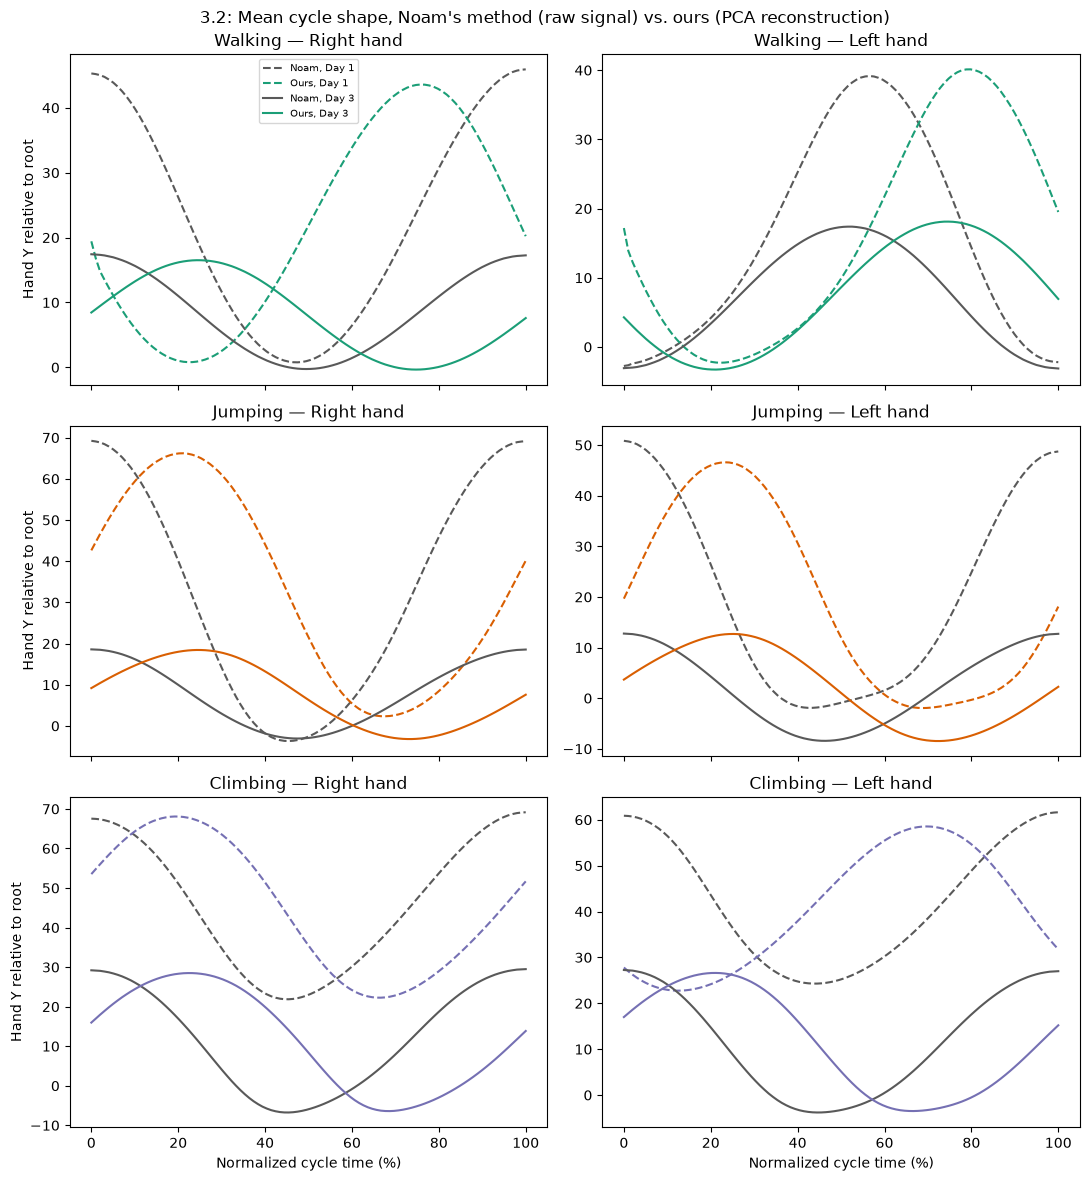

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(11, 12), sharex=True)
for i, skill in enumerate(["walk", "jump", "climb"]):
    for j, hand in enumerate(["r_hand", "l_hand"]):
        ax = axes[i, j]
        any_plotted = False
        for (day, part, sk, hd), shapes in mean_shapes.items():
            if sk != skill or hd != hand:
                continue
            t = np.linspace(0, 100, 100)
            if shapes["noam"] is not None:
                ax.plot(t, shapes["noam"], color="0.35", linestyle=P.DAY_LINESTYLES[day],
                        label=f"Noam, Day {day}")
                any_plotted = True
            if shapes["ours"] is not None:
                ax.plot(t, shapes["ours"], color=P.SKILL_COLORS[skill], linestyle=P.DAY_LINESTYLES[day],
                        label=f"Ours, Day {day}")
                any_plotted = True
        ax.set_title(f"{P.SKILL_LABELS[skill]} — {P.HAND_LABELS[hand]}")
        if not any_plotted:
            ax.text(0.5, 0.5, "no data", ha="center", va="center", transform=ax.transAxes)
        if i == 0 and j == 0:
            ax.legend(fontsize=7)
axes[-1, 0].set_xlabel("Normalized cycle time (%)")
axes[-1, 1].set_xlabel("Normalized cycle time (%)")
for ax in axes[:, 0]:
    ax.set_ylabel("Hand Y relative to root")
fig.suptitle("3.2: Mean cycle shape, Noam's method (raw signal) vs. ours (PCA reconstruction)")
fig.tight_layout()
P.save_figure(fig, "stage3_mean_cycle_shape_comparison")
plt.show()


## Summary numbers for PROGRESS.md

In [7]:
print("=== 3.1 boundary offsets by skill (seconds) ===")
print(offsets_df.groupby("skill")["offset_sec"].describe()[["50%", "25%", "75%", "count"]])
print()
print("=== 3.1 phase-warning rate by skill ===")
print(warn_df.groupby("skill")["has_phase_warning"].mean())
print()
print("=== 3.2 cycle count / duration comparison ===")
print(comparison_df.to_string(index=False))


=== 3.1 boundary offsets by skill (seconds) ===
            50%       25%       75%  count
skill                                     
climb  0.183333  0.150000  0.266667  672.0
jump   0.200000  0.183333  0.233333  651.0
walk   0.166667  0.133333  0.250000  670.0

=== 3.1 phase-warning rate by skill ===
skill
climb    0.000
jump     0.025
walk     0.000
Name: has_phase_warning, dtype: float64

=== 3.2 cycle count / duration comparison ===
 day part skill   hand  n_cycles_ours  n_cycles_noam  median_duration_ours  median_duration_noam
   1    s climb r_hand             20             18              1.066667              1.066667
   1    s climb l_hand             21             18              1.116667              1.066667
   1    s  jump r_hand             10              8              0.925000              0.925000
   1    s  jump l_hand             10              9              0.950000              0.916667
   1    s  walk r_hand             26             24              1.03333